In [1]:
import sys
sys.path
sys.path.append(r"../")
sys.path.append(r'C:\Users\sadiq\Desktop\U_Vienna\codes\icm-zebrafish')
import numpy as np
import matplotlib.pyplot as plt
from d_CSL import *
from new_utils import *
import d_CSL
from tqdm.notebook import tqdm
import seaborn as sns
import pandas as pd

In [2]:
%reload_ext autoreload
%autoreload 2
from d_CSL import *

In [47]:
# load data 
data = pd.read_csv(r'./data/NTS-NOTEARS/X.csv', header=None)
X_ = data.values
X = X_.T
print(X.shape)

A_ = pd.read_csv(r'./data/NTS-NOTEARS/W_true.csv', header=None)
A = A_.values

(5, 5000)


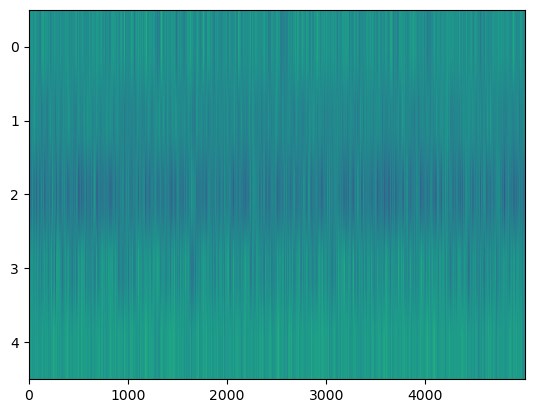

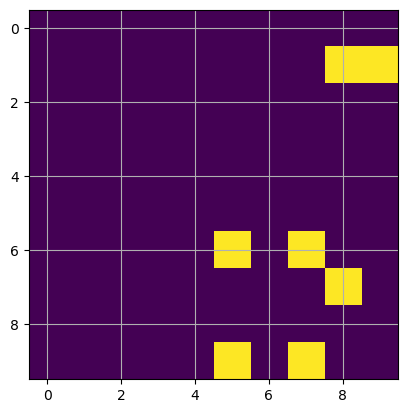

In [4]:
plt.figure()
plt.imshow(X, aspect='auto')

plt.figure()
plt.imshow(A!=0)
plt.grid()

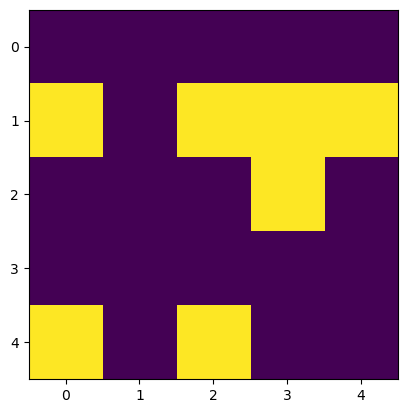

In [5]:
B = np.array([[0,0,0,0,0],
              [1,0,1,1,1],
              [0,0,0,1,0],
              [0,0,0,0,0],
              [1,0,1,0,0]])

plt.imshow(B)

In [6]:
n_neur,n_perm,alpha,beta,n_lags = X.shape[0],2000,0,0.05,2

### Analysis

In [7]:
def proceed_GC_(corr,pVal_corr,inv_corr,pVal_inv_corr,alpha,beta,n_past,n_lags):
    sig_corr = np.multiply(corr,pVal_corr<=alpha)        # compute significant correlation matrix
    sig_inv = np.multiply(inv_corr,pVal_inv_corr<=beta)  # compute significant partial correlation matrix
    inferred = np.logical_and(sig_corr,sig_inv)          # inferred matrix
    plott_(inferred,n_past)
    b, all_, n_neur = 0, [], inferred.shape[1]

    # merging results for the GC order used
    for a in range(n_past+1):
        all_.append(inferred[a*n_neur:(a+1)*n_neur,b*n_neur:(b+1)*n_neur])
    new_inf = all_[0]
    for i in range(1,n_lags+1):        # use 'nn' if all matrices are to be used, here i take out the last one
        new_inf = np.logical_or(new_inf,all_[i])
#     new_inf = np.multiply(corr[:n_neur,:], new_inf)   # multiplied with correlation to determine the strength of connections
    np.fill_diagonal(new_inf, 0)      # self connectivity removed
    plt.figure()
    plt.imshow(mat_func(B, new_inf))
    plt.colorbar()
    return new_inf # take into account variations in lags

2


C:\Users\sadiq\Desktop\U_Vienna\codes\icm-zebrafish\d_CSL.py:119: NumbaExperimentalFeatureWarning: Use of isinstance() detected. This is an experimental feature.
  count,corr_1 = 0,np.corrcoef(x,y)[1,0]


3
4
5
CPU times: total: 5min 16s
Wall time: 2min 9s


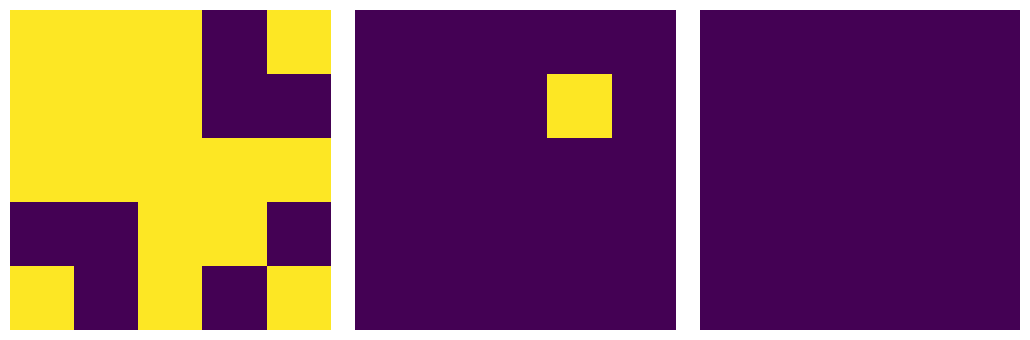

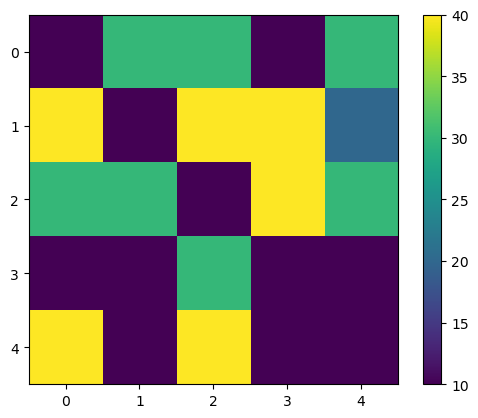

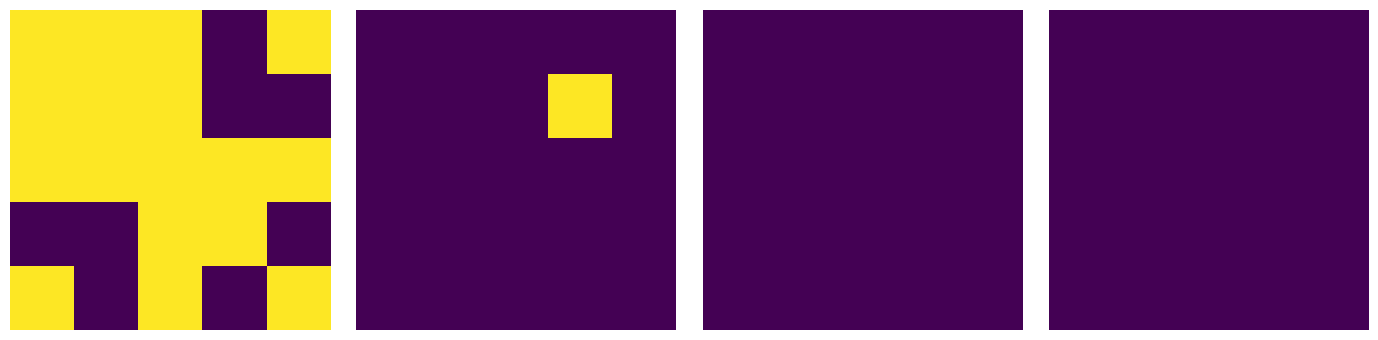

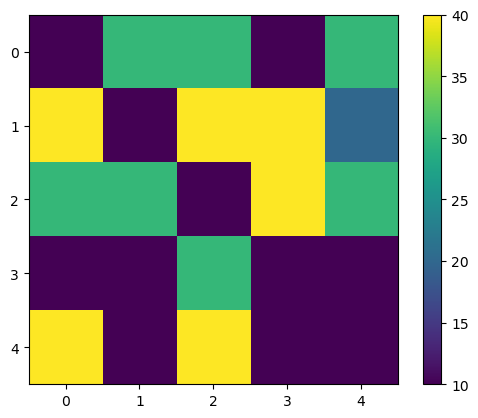

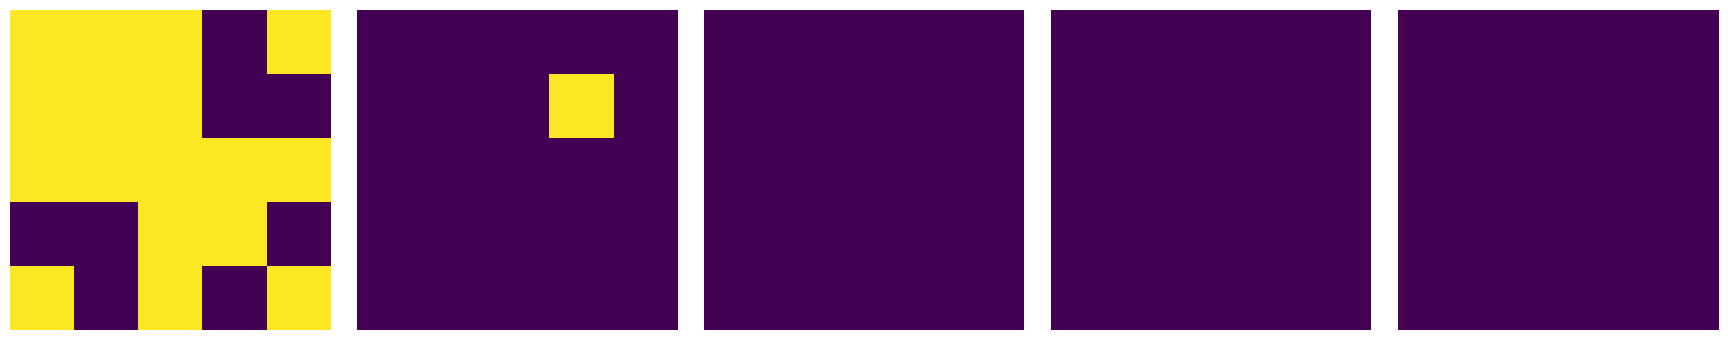

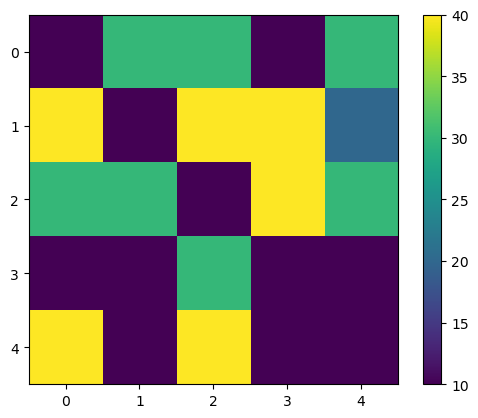

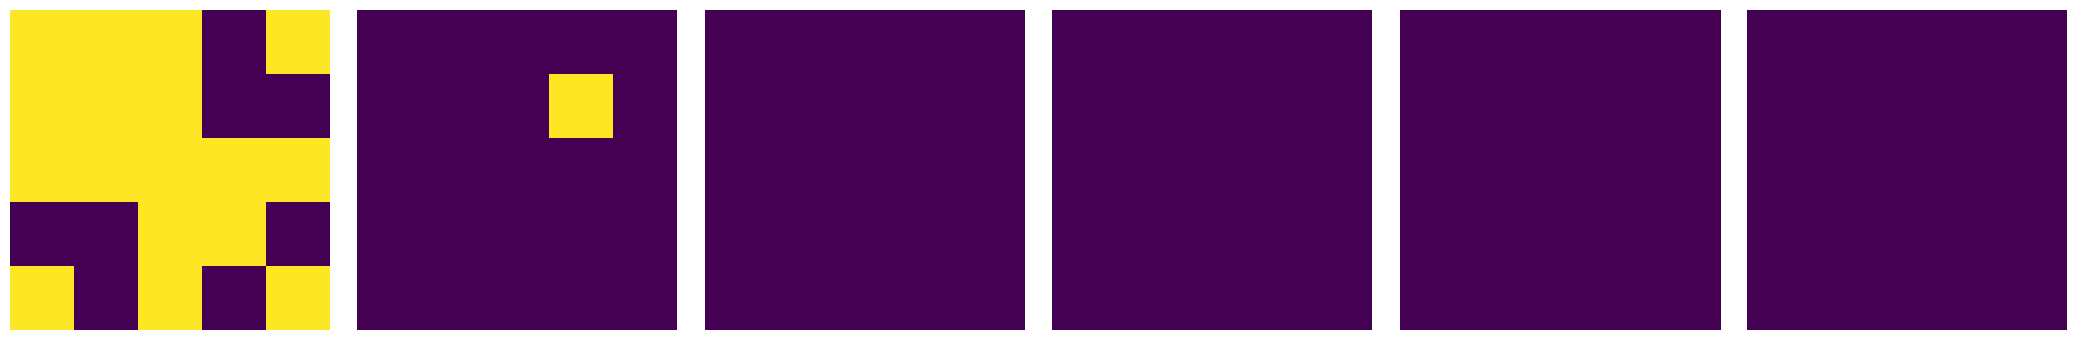

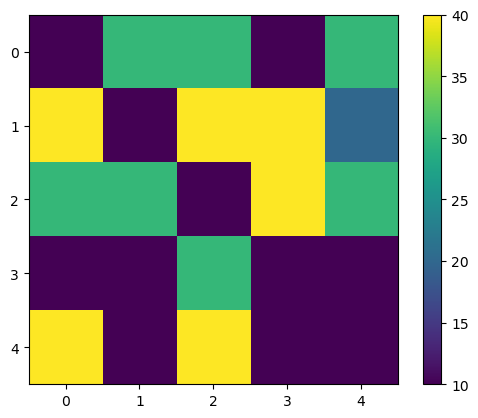

In [8]:
%%time
n_pasts = np.arange(2,6,1)
for n in n_pasts:
    print(n)
    corr,pVal_corr,inv_corr,pVal_inv_corr = analysis_GC(X,n_perm,n) # proceed
# L = [corr,pVal_corr,inv_corr,pVal_inv_corr]
# fig,ax = plt.subplots(1,4,figsize=(12,7))
# for i in range(4):
#     ax[i].imshow(L[i])
# plt.tight_layout()
    proceed_GC_(corr,pVal_corr,inv_corr,pVal_inv_corr,alpha,beta,n,n_lags)

In [9]:
stop

NameError: name 'stop' is not defined